![arnold](forest.jpg)
# 🧠 Técnicas de Inteligencia Artificial (TIA)
## 📝 Taller 4: Modelos Clásicos de ML - Reconocimiento de Patrones

## Objetivo general:
- Resolver, utilizando técnicas clásicas de Machine Learning, el mismo problema de clasificación multiclase abordado con MLP (taller de Redes Neuronales), y con la misma base de datos de dicho taller.
- Comparar el desempeño de las técnicas implementadas con el modelo profundo (MLP) previamente desarrollado.

## Pautas de implementación:
- Implementar al menos dos modelos clásicos de clasificación supervisada.
- Todos los modelos deben entrenarse con: el mismo conjunto de entrenamiento y las mismas características de entrada.
- Ajustar hiperparámetros de cada modelo.
- Evaluar cada modelo en condiciones idénticas, en particular usar el mismo conjunto de validación.
- Comparar los resultados con el MLP del taller anterior.


### 1. Carga y Partición de Datos
Importamos las librerías necesarias, cargamos el dataset de Olivetti Faces y realizamos la partición de los datos en entrenamiento (60%), validación (20%) y prueba (20%), usando `stratify` para mantener la proporción de clases.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split

print("1. Cargando dataset de Olivetti Faces...")
faces = fetch_olivetti_faces(shuffle=True, random_state=42)
X, y = faces.data, faces.target

print("2. Aplicando partición consistente con el Taller 3 (Hold-out 60/20/20)...")
semilla = 42

# Primera partición: 60% Train, 40% Temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=semilla, stratify=y
)
# Segunda partición: 20% Val, 20% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=semilla, stratify=y_temp
)

print(f"Dimensiones - Entrenamiento: {X_train.shape[0]} | Validación: {X_val.shape[0]} | Prueba: {X_test.shape[0]}")


1. Cargando dataset de Olivetti Faces...
2. Aplicando partición consistente con el Taller 3 (Hold-out 60/20/20)...
Dimensiones - Entrenamiento: 240 | Validación: 80 | Prueba: 80


### 2. Modelo Base: Árbol de Decisión
Implementamos un DecisionTreeClassifier como modelo base clásico para establecer un punto de comparación.


In [3]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

print("Entrenando Árbol de Decisión (DecisionTreeClassifier)...")

# Control de complejidad (Poda) para evitar sobreajuste
clf_tree = DecisionTreeClassifier(
    criterion="entropy",       # Medida de impureza usada en el ejemplo del profe
    max_depth=12,              # Limitamos la profundidad máxima
    min_samples_split=5,       # Mínimo de muestras para dividir un nodo
    random_state=semilla
)

# Entrenar el modelo con el conjunto de entrenamiento
clf_tree.fit(X_train, y_train)

# Métricas de Comparación (Evaluamos en Validación para contrastar con el MLP)
y_pred_val = clf_tree.predict(X_val)
acc_val = accuracy_score(y_val, y_pred_val)

print(f"\n✅ Accuracy en el conjunto de VALIDACIÓN: {acc_val:.4f}")


Entrenando Árbol de Decisión (DecisionTreeClassifier)...

✅ Accuracy en el conjunto de VALIDACIÓN: 0.5000


### 3. Importancia de Características (Decision Tree)
Extraemos y graficamos la importancia de cada característica (píxel) según la reducción de impureza de Gini/Entropía que aporta al árbol de decisión.


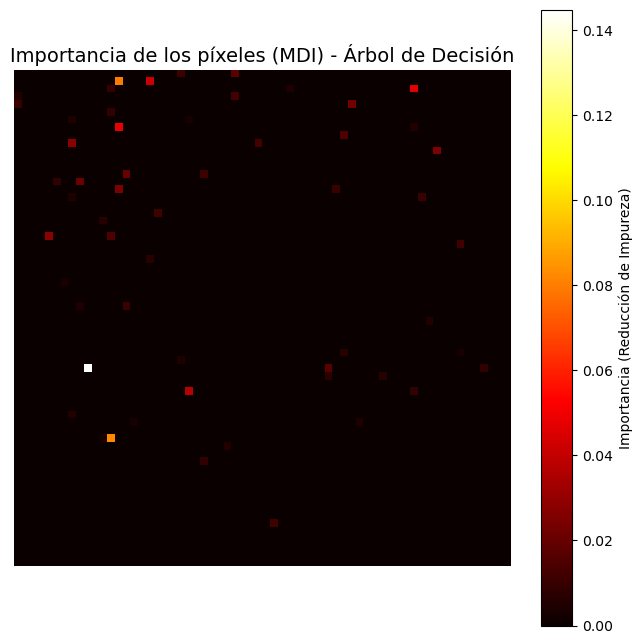

In [4]:
# Extraer la importancia de las características (basado en la reducción de impureza)
importances = clf_tree.feature_importances_

# Redimensionar el vector de 4096 a la forma original de la imagen (64x64)
importances_img = importances.reshape(64, 64)

# Visualización con mapa de calor (cmap='hot' como en el ejemplo del profesor)
plt.figure(figsize=(8, 8))
plt.imshow(importances_img, cmap="hot", interpolation="nearest")
plt.title("Importancia de los píxeles (MDI) - Árbol de Decisión", fontsize=14)
plt.colorbar(label="Importancia (Reducción de Impureza)")
plt.axis('off')
plt.show()


### 4. Visualización de Reglas del Árbol
Renderizamos gráficamente los primeros niveles del Árbol de Decisión para entender su estructura de ramificación.


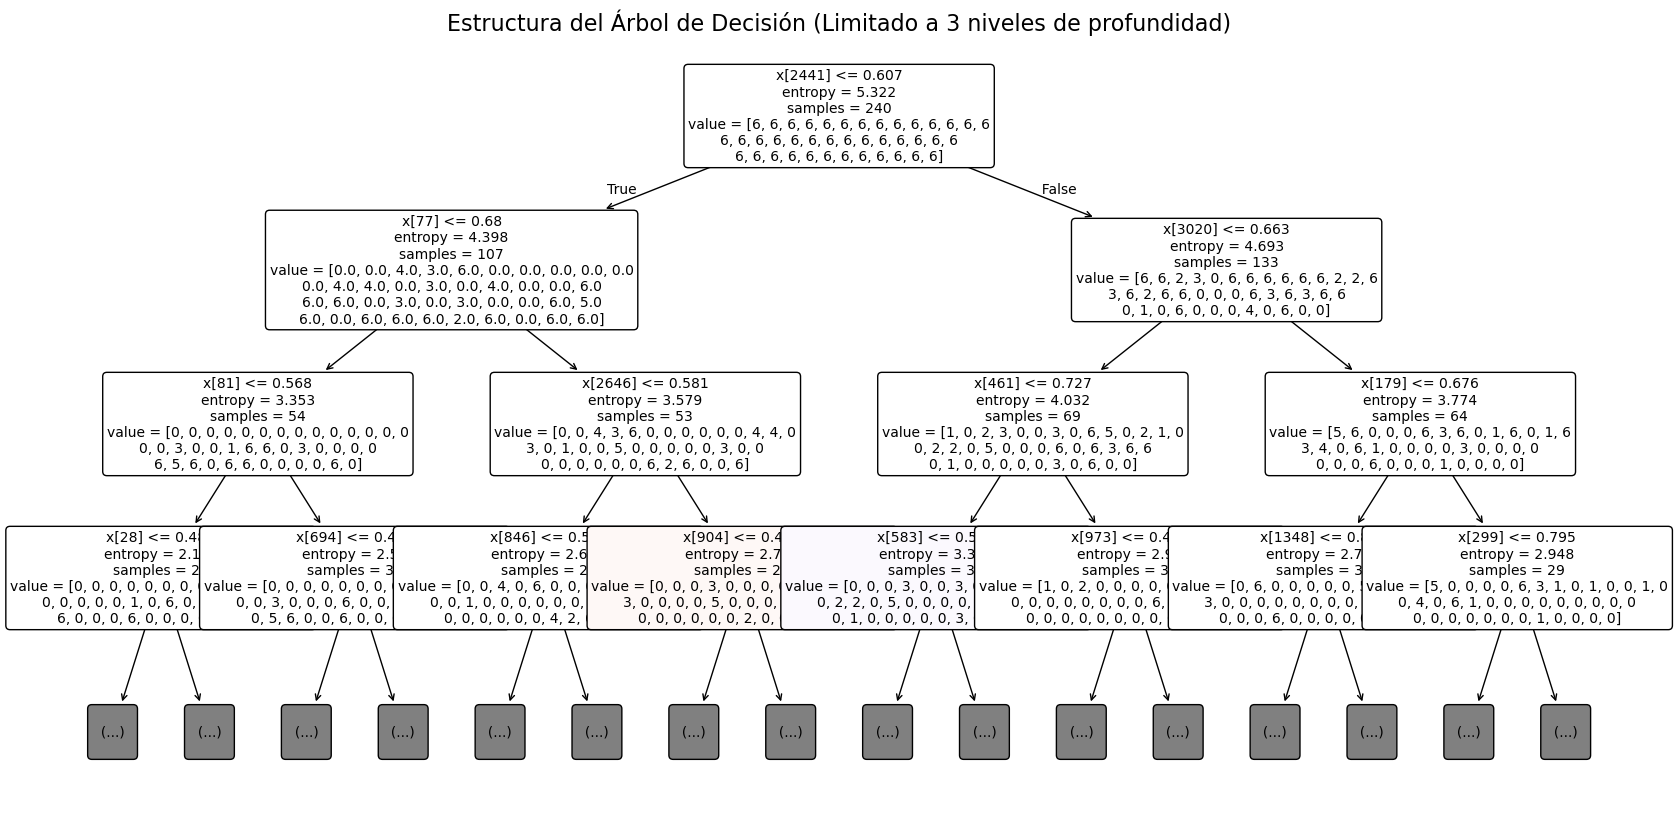

In [5]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

# Limitamos la visualización a los primeros 3 niveles (max_depth=3) en la gráfica
plot_tree(clf_tree,
          max_depth=3,
          filled=True, 
          rounded=True,
          fontsize=10)

plt.title("Estructura del Árbol de Decisión (Limitado a 3 niveles de profundidad)", fontsize=16)
plt.show()


### 5. Inferencia Visual con Árbol de Decisión
Definimos una función para visualizar gráficamente algunas predicciones del modelo sobre las imágenes reales.


C:\Users\yoshikagua\AppData\Local\Temp\ipykernel_30084\2710863409.py:32: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\yoshikagua\miniconda3\envs\ai_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


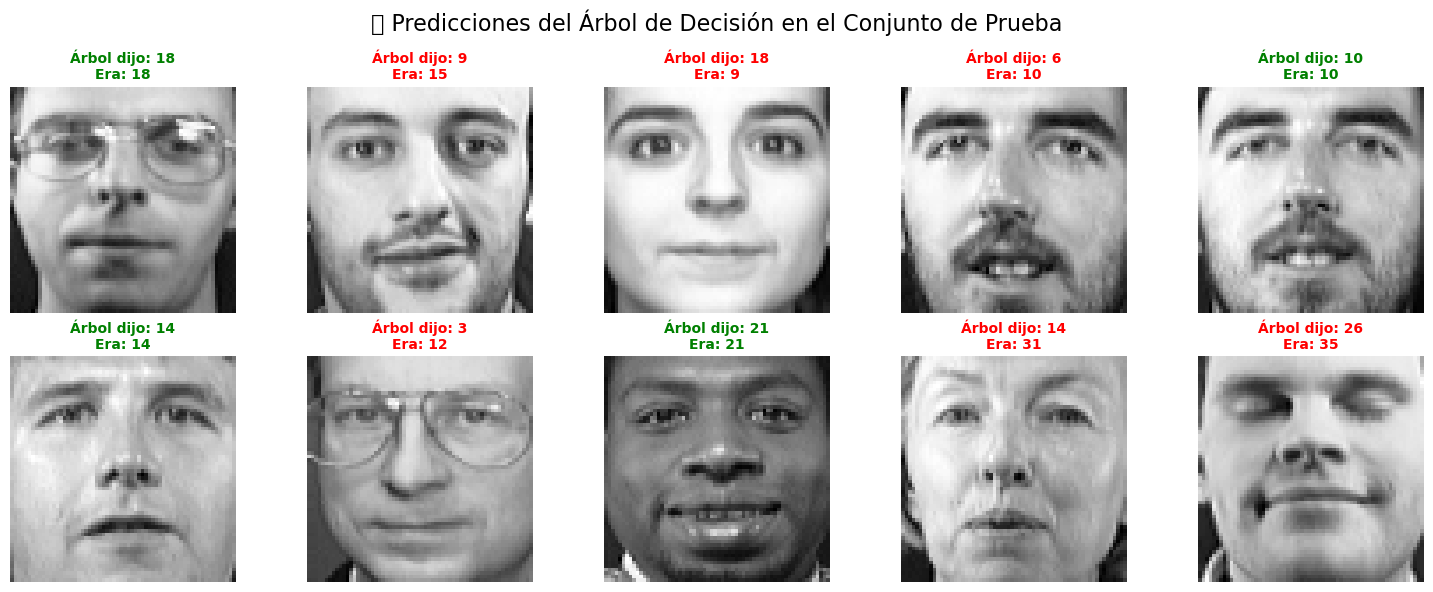

In [6]:
def visualizar_resultados_arbol(modelo, X_imagenes, y_reales, cantidad=10):
    """
    Muestra una cuadrícula de imágenes con las predicciones del Árbol de Decisión.
    """
    # 1. Obtener predicciones
    # El árbol usa los datos tal cual (X_imagenes ya son vectores de 4096)
    predicciones = modelo.predict(X_imagenes)
    
    # 2. Seleccionar índices aleatorios
    np.random.seed(42) # Para que las fotos sean consistentes en el reporte
    indices = np.random.choice(len(y_reales), cantidad, replace=False)
    
    # 3. Configurar la visualización
    plt.figure(figsize=(15, 6))
    plt.suptitle("🌲 Predicciones del Árbol de Decisión en el Conjunto de Prueba", fontsize=16)
    
    for i, idx in enumerate(indices):
        plt.subplot(2, 5, i + 1)
        
        # Redimensionar el vector de píxeles a 64x64
        foto = X_imagenes[idx].reshape(64, 64)
        plt.imshow(foto, cmap='gray')
        plt.axis('off')
        
        pred = predicciones[idx]
        real = y_reales[idx]
        
        # Color verde si acertó, rojo si falló
        color = 'green' if pred == real else 'red'
        plt.title(f"Árbol dijo: {pred}\nEra: {real}", color=color, fontweight='bold', fontsize=10)
        
    plt.tight_layout()
    plt.show()

# Ejecutamos la visualización con los datos de PRUEBA (X_test, y_test)
visualizar_resultados_arbol(clf_tree, X_test, y_test, cantidad=10)


### 6. Modelo Base: Random Forest
Entrenamos un modelo de ensamble tipo Bosque Aleatorio inicial para comparar su desempeño con el árbol simple.


In [7]:
from sklearn.ensemble import RandomForestClassifier

# Crear el modelo de Bosque Aleatorio
# Bootstrap: Crea sub-conjuntos aleatorios con reemplazo para entrenar cada árbol.
# Max_features: Selecciona solo una parte aleatoria de los píxeles en cada división,
#               lo que reduce la correlación entre árboles y mejora la generalización.
clf_rf = RandomForestClassifier(
    n_estimators=200,      # Número de árboles en el bosque
    max_depth=None,        # Dejamos que los árboles crezcan para capturar varianza
    max_features='sqrt',   # Selección aleatoria de atributos (sqrt de 4096)
    random_state=semilla,
    n_jobs=-1              # Usar todos los núcleos del procesador
)

# Entrenar el modelo
clf_rf.fit(X_train, y_train)

# Evaluación inicial en validación
y_pred_rf_val = clf_rf.predict(X_val)
acc_rf_val = accuracy_score(y_val, y_pred_rf_val)

print(f"✅ Accuracy del Random Forest en VALIDACIÓN: {acc_rf_val:.4f}")


✅ Accuracy del Random Forest en VALIDACIÓN: 0.9625


### 7. Análisis de Estimadores en Random Forest
Evaluamos cómo cambia el accuracy del modelo en función del número de árboles (estimadores) en el ensamble.


Probando diferentes tamaños de bosque...
 - Árboles:   1 | Accuracy: 0.4375
 - Árboles:  10 | Accuracy: 0.7750
 - Árboles:  30 | Accuracy: 0.8625
 - Árboles:  50 | Accuracy: 0.9375
 - Árboles: 100 | Accuracy: 0.9500
 - Árboles: 200 | Accuracy: 0.9625
 - Árboles: 300 | Accuracy: 0.9625


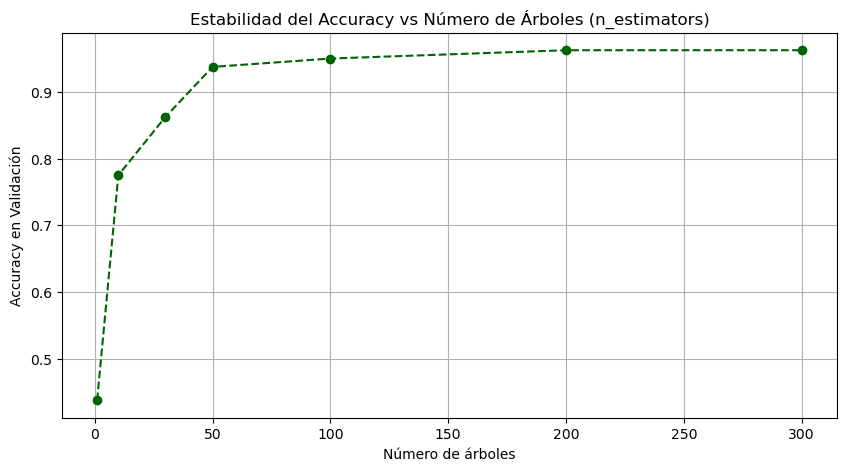

In [8]:
# Valores de n_estimators a probar (siguiendo la guía del profesor)
estimadores_lista = [1, 10, 30, 50, 100, 200, 300]
precisones_lista = []

print("Probando diferentes tamaños de bosque...")
for n in estimadores_lista:
    modelo_temp = RandomForestClassifier(n_estimators=n, random_state=semilla, n_jobs=-1)
    modelo_temp.fit(X_train, y_train)
    score = accuracy_score(y_val, modelo_temp.predict(X_val))
    precisones_lista.append(score)
    print(f" - Árboles: {n:3} | Accuracy: {score:.4f}")

# Graficar resultados
plt.figure(figsize=(10, 5))
plt.plot(estimadores_lista, precisones_lista, marker='o', color='darkgreen', linestyle='--')
plt.title("Estabilidad del Accuracy vs Número de Árboles (n_estimators)")
plt.xlabel("Número de árboles")
plt.ylabel("Accuracy en Validación")
plt.grid(True)
plt.show()


### 8. Importancia de Características (Random Forest)
Revisamos qué píxeles son más importantes para el Random Forest, promediando la importancia en todos sus árboles.


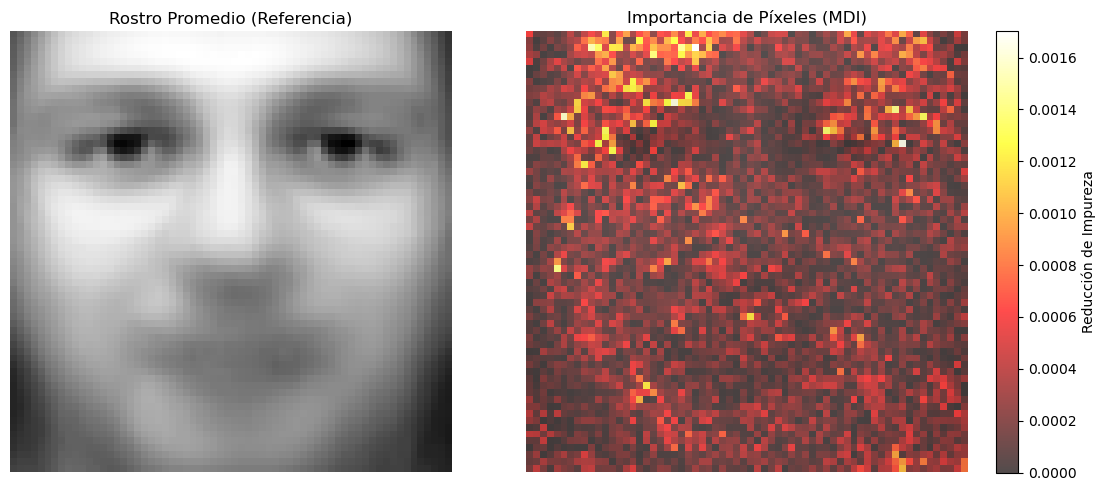

In [9]:
# 1. Calcular importancia de características (MDI)
importancias_rf = clf_rf.feature_importances_
importancias_img = importancias_rf.reshape(64, 64)

# 2. Calcular la "cara promedio" del dataset para referencia visual
cara_promedio = X_train.mean(axis=0).reshape(64, 64)

# 3. Graficar comparativa
plt.figure(figsize=(12, 5))

# Rostro Promedio
plt.subplot(1, 2, 1)
plt.imshow(cara_promedio, cmap='gray')
plt.title("Rostro Promedio (Referencia)")
plt.axis('off')

# Mapa de calor de importancia
plt.subplot(1, 2, 2)
plt.imshow(cara_promedio, cmap='gray', alpha=0.3) # Cara de fondo tenue
plt.imshow(importancias_img, cmap='hot', alpha=0.7) # Importancia encima
plt.title("Importancia de Píxeles (MDI)")
plt.colorbar(label='Reducción de Impureza')
plt.axis('off')

plt.tight_layout()
plt.show()


### 9. Comparación Preliminar
Generamos un cuadro comparativo inicial entre el Árbol, Random Forest base y el MLP (Taller 3).


In [10]:
import pandas as pd

# Reemplaza 'acc_mlp' con el valor exacto de tu mejor modelo en el Taller 3
acc_mlp = 0.9750 # Valor de referencia de tu Random Search previo

data_comparativa = {
    "Modelo": ["Árbol de Decisión Único", "Random Forest (Ensamble)", "MLP (Red Neuronal)"],
    "Accuracy Validación": [acc_val, acc_rf_val, acc_mlp],
    "Tipo de Algoritmo": ["Clásico (Débil)", "Clásico (Ensamble)", "Aprendizaje Profundo"]
}

df_comparativa = pd.DataFrame(data_comparativa)
print("\n📋 TABLA COMPARATIVA DE DESEMPEÑO")
display(df_comparativa)



📋 TABLA COMPARATIVA DE DESEMPEÑO


,Modelo,Accuracy Validación,Tipo de Algoritmo
0,Árbol de Decisión Único,0.5000,Clásico (Débil)
1,Random Forest (Ensamble),0.9625,Clásico (Ensamble)
2,MLP (Red Neuronal),0.9750,Aprendizaje Profundo


### 10. Inspección Interna del Bosque Aleatorio
Visualizamos algunos árboles individuales que componen el Random Forest.


C:\Users\yoshikagua\AppData\Local\Temp\ipykernel_30084\2627511320.py:23: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\yoshikagua\miniconda3\envs\ai_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


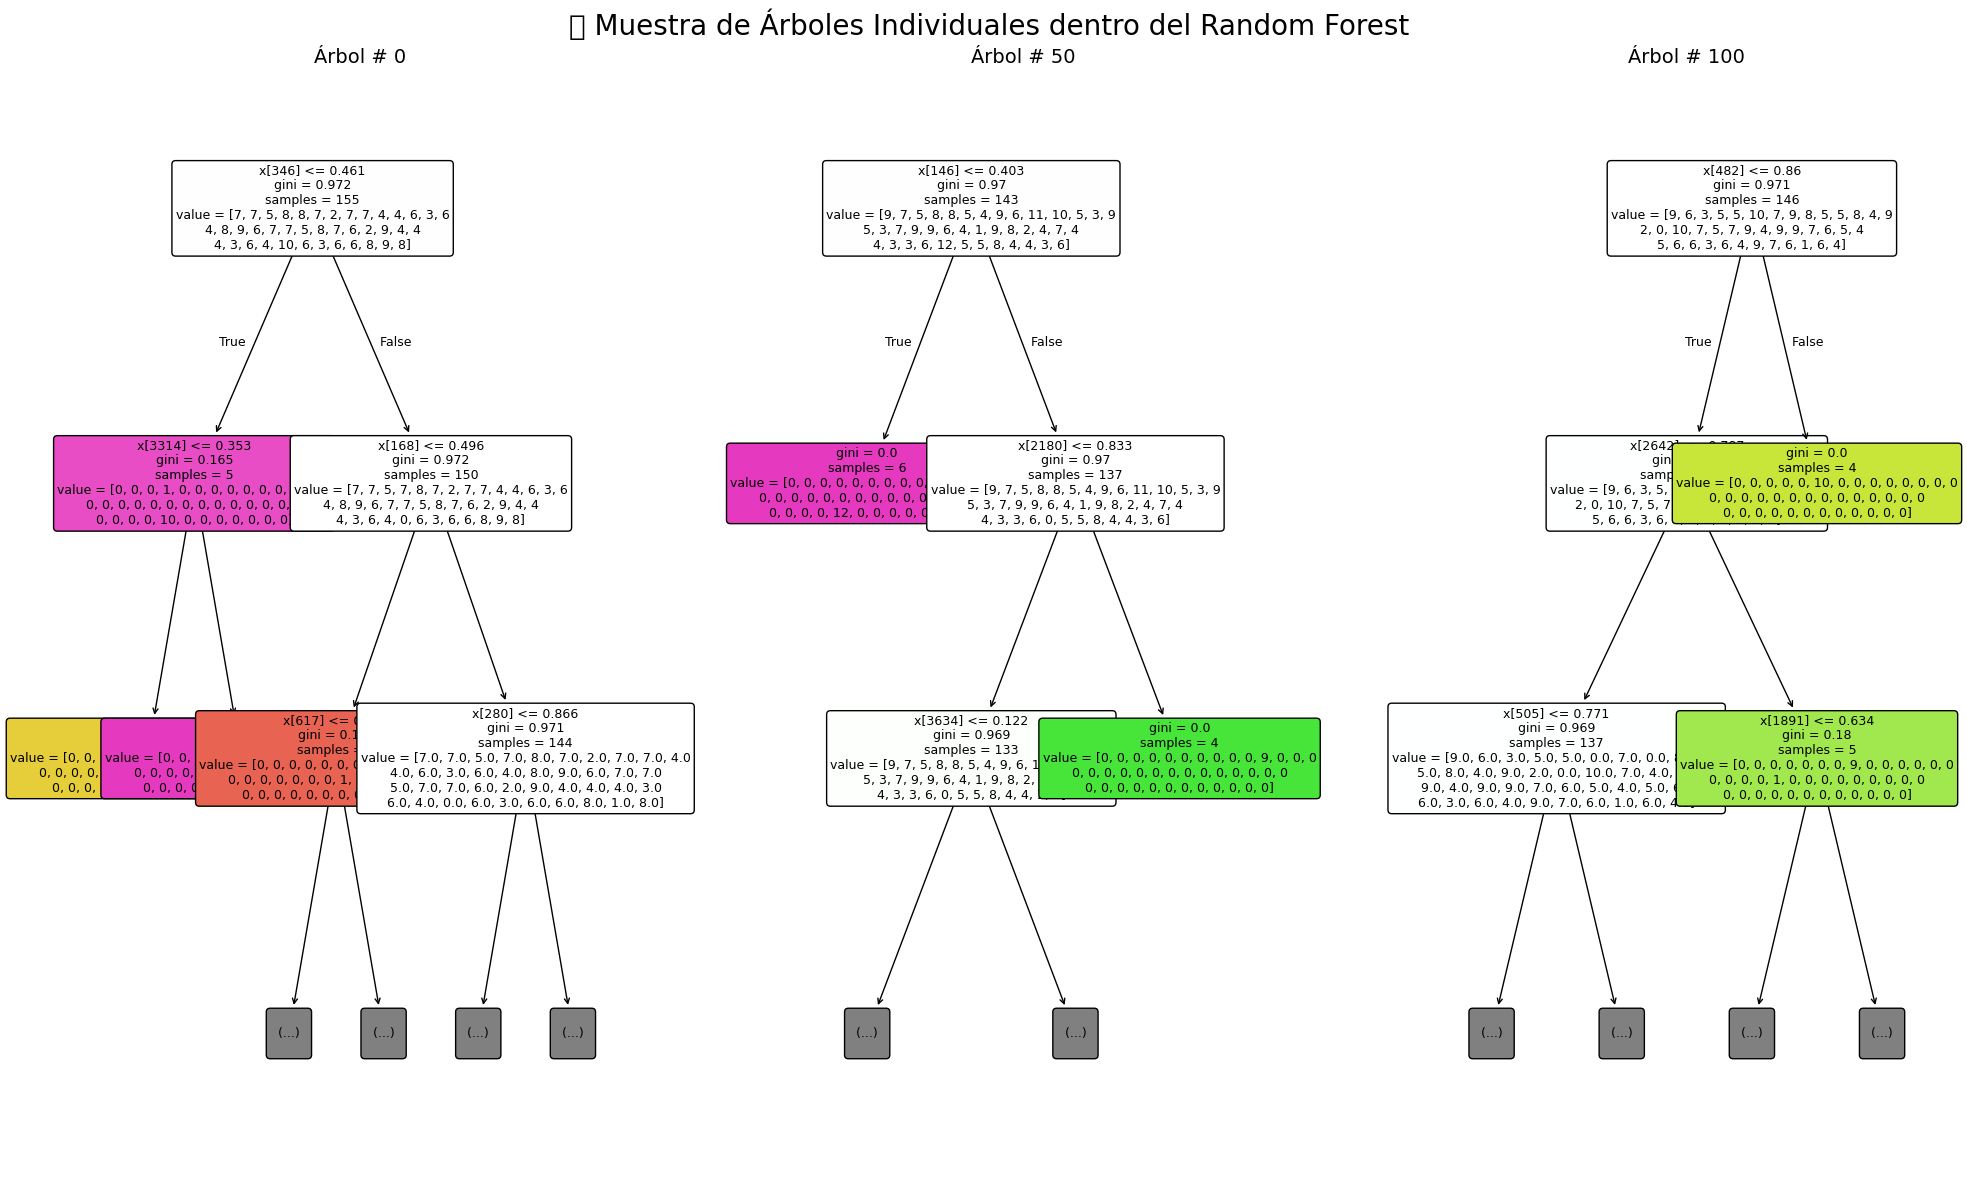

In [11]:
from sklearn.tree import plot_tree

# Vamos a visualizar 3 árboles diferentes del bosque (por ejemplo, el 0, el 50 y el 100)
arboles_a_ver = [0, 50, 100]

plt.figure(figsize=(20, 12))
plt.suptitle("🌲 Muestra de Árboles Individuales dentro del Random Forest", fontsize=20)

for i, idx_arbol in enumerate(arboles_a_ver):
    plt.subplot(1, 3, i + 1)
    # Extraemos el árbol específico del bosque
    arbol_individual = clf_rf.estimators_[idx_arbol]
    
    # Graficamos con profundidad limitada para que sea legible
    plot_tree(arbol_individual, 
              max_depth=2, 
              filled=True, 
              rounded=True, 
              fontsize=9)
    
    plt.title(f"Árbol # {idx_arbol}", fontsize=14)

plt.tight_layout()
plt.show()


### 11. Votación del Bosque Aleatorio
Definimos una función para observar cómo 'votan' los distintos árboles del ensamble para llegar a la predicción final de una imagen.


C:\Users\yoshikagua\AppData\Local\Temp\ipykernel_30084\4153781650.py:36: UserWarning: Glyph 128499 (\N{BALLOT BOX WITH BALLOT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\yoshikagua\miniconda3\envs\ai_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128499 (\N{BALLOT BOX WITH BALLOT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


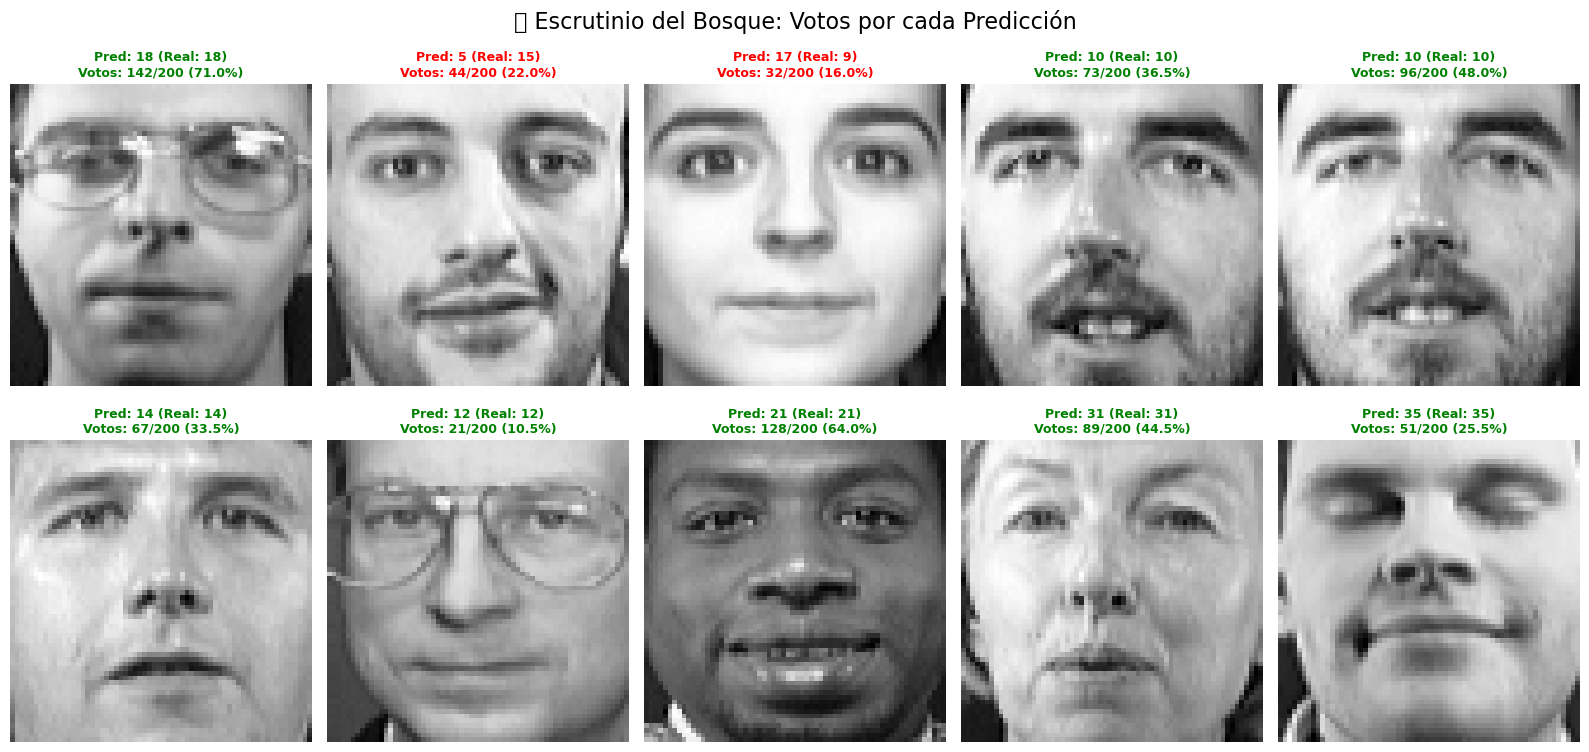

In [12]:
def visualizar_votacion_bosque(modelo, X_imagenes, y_reales, cantidad=10):
    # 1. Obtener la predicción final (voto mayoritario)
    pred_final = modelo.predict(X_imagenes)
    
    # 2. Obtener los votos de CADA uno de los árboles individuales
    # 'estimators_' contiene los 200 árboles. Creamos una matriz de votos.
    votos_todos_los_arboles = np.array([tree.predict(X_imagenes) for tree in modelo.estimators_])
    
    np.random.seed(42)
    indices = np.random.choice(len(y_reales), cantidad, replace=False)
    
    plt.figure(figsize=(16, 8))
    plt.suptitle("🗳️ Escrutinio del Bosque: Votos por cada Predicción", fontsize=16)
    
    for i, idx in enumerate(indices):
        plt.subplot(2, 5, i + 1)
        foto = X_imagenes[idx].reshape(64, 64)
        plt.imshow(foto, cmap='gray')
        plt.axis('off')
        
        ganador = pred_final[idx]
        real = y_reales[idx]
        
        # Contar cuántos árboles votaron por el ganador
        conteo_votos = np.sum(votos_todos_los_arboles[:, idx] == ganador)
        total_arboles = len(modelo.estimators_)
        porcentaje = (conteo_votos / total_arboles) * 100
        
        color = 'green' if ganador == real else 'red'
        
        # Título con el escrutinio
        plt.title(f"Pred: {ganador} (Real: {real})\n"
                  f"Votos: {conteo_votos}/{total_arboles} ({porcentaje:.1f}%)", 
                  color=color, fontweight='bold', fontsize=9)
        
    plt.tight_layout()
    plt.show()

# Ejecutamos la visualización de votos
visualizar_votacion_bosque(clf_rf, X_test, y_test, cantidad=10)


### 12. Modelo Base: Gradient Boosting
Implementamos un modelo de ensamble secuencial (Gradient Boosting Machine) para evaluar su desempeño en los datos.


In [13]:
from sklearn.ensemble import GradientBoostingClassifier

print("Entrenando Gradient Boosting Machine... (Esto puede tomar un par de minutos)")

# Configuración del modelo GBM con parámetros de regularización
clf_gbm = GradientBoostingClassifier(
    n_estimators=150,        # M: Número de iteraciones (cuántos árboles se sumarán)
    learning_rate=0.1,       # η: Tasa de aprendizaje (controla el aporte de cada nuevo árbol)
    max_depth=3,             # Árboles débiles (stumps/poca profundidad)
    subsample=0.8,           # Muestreo estocástico (usa el 80% de los datos en cada paso para evitar sobreajuste)
    random_state=semilla
)

# Entrenamiento secuencial (aditivo)
clf_gbm.fit(X_train, y_train)

# Evaluación en validación
y_pred_gbm_val = clf_gbm.predict(X_val)
acc_gbm_val = accuracy_score(y_val, y_pred_gbm_val)

print(f"\n✅ Accuracy de Gradient Boosting en VALIDACIÓN: {acc_gbm_val:.4f}")


Entrenando Gradient Boosting Machine... (Esto puede tomar un par de minutos)

✅ Accuracy de Gradient Boosting en VALIDACIÓN: 0.6625


### 13. Curva de Aprendizaje del Gradient Boosting
Observamos cómo evoluciona el accuracy iteración tras iteración usando el método `staged_predict`.


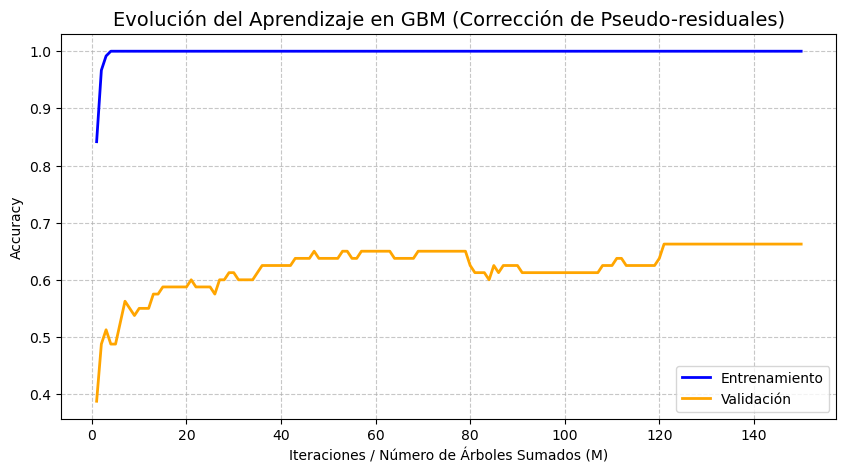

In [14]:
# Listas para almacenar el accuracy en cada paso
acc_train_staged = []
acc_val_staged = []

# staged_predict evalúa el modelo usando solo los primeros 'i' árboles
for y_pred_train_step in clf_gbm.staged_predict(X_train):
    acc_train_staged.append(accuracy_score(y_train, y_pred_train_step))

for y_pred_val_step in clf_gbm.staged_predict(X_val):
    acc_val_staged.append(accuracy_score(y_val, y_pred_val_step))

# Graficar la evolución
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(acc_train_staged) + 1), acc_train_staged, label='Entrenamiento', color='blue', linewidth=2)
plt.plot(range(1, len(acc_val_staged) + 1), acc_val_staged, label='Validación', color='orange', linewidth=2)

plt.title("Evolución del Aprendizaje en GBM (Corrección de Pseudo-residuales)", fontsize=14)
plt.xlabel("Iteraciones / Número de Árboles Sumados (M)")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


### 14. Comparación de Modelos Base
Actualizamos el cuadro comparativo incluyendo los resultados del Gradient Boosting.


In [15]:
import pandas as pd

# Consolidamos todos los resultados del Taller 3 y 4
data_final = {
    "Modelo": [
        "Árbol de Decisión Único", 
        "Random Forest", 
        "Gradient Boosting (GBM)", 
        "MLP (Red Neuronal Profunda)"
    ],
    "Accuracy Validación": [acc_val, acc_rf_val, acc_gbm_val, acc_mlp], # Variables de celdas previas
    "Estrategia Principal": [
        "Reglas simples (Propenso a sobreajuste)", 
        "Reducción de Varianza (Votación Paralela)", 
        "Reducción de Sesgo (Corrección Secuencial)", 
        "Extracción Jerárquica de Características"
    ]
}

# Crear DataFrame y ordenarlo del mejor al peor
df_final = pd.DataFrame(data_final)
df_final = df_final.sort_values(by="Accuracy Validación", ascending=False).reset_index(drop=True)

print("🏆 TABLA COMPARATIVA DEFINITIVA DE MODELOS")
display(df_final.style.background_gradient(subset=["Accuracy Validación"], cmap="Greens"))


🏆 TABLA COMPARATIVA DEFINITIVA DE MODELOS


,Modelo,Accuracy Validación,Estrategia Principal
0,MLP (Red Neuronal Profunda),0.975000,Extracción Jerárquica de Características
1,Random Forest,0.962500,Reducción de Varianza (Votación Paralela)
2,Gradient Boosting (GBM),0.662500,Reducción de Sesgo (Corrección Secuencial)
3,Árbol de Decisión Único,0.500000,Reglas simples (Propenso a sobreajuste)


### 15. Estructura Interna del GBM
Visualizamos uno de los árboles construidos por el Gradient Boosting para corregir errores secuenciales.


C:\Users\yoshikagua\AppData\Local\Temp\ipykernel_30084\2713954093.py:27: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\yoshikagua\miniconda3\envs\ai_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


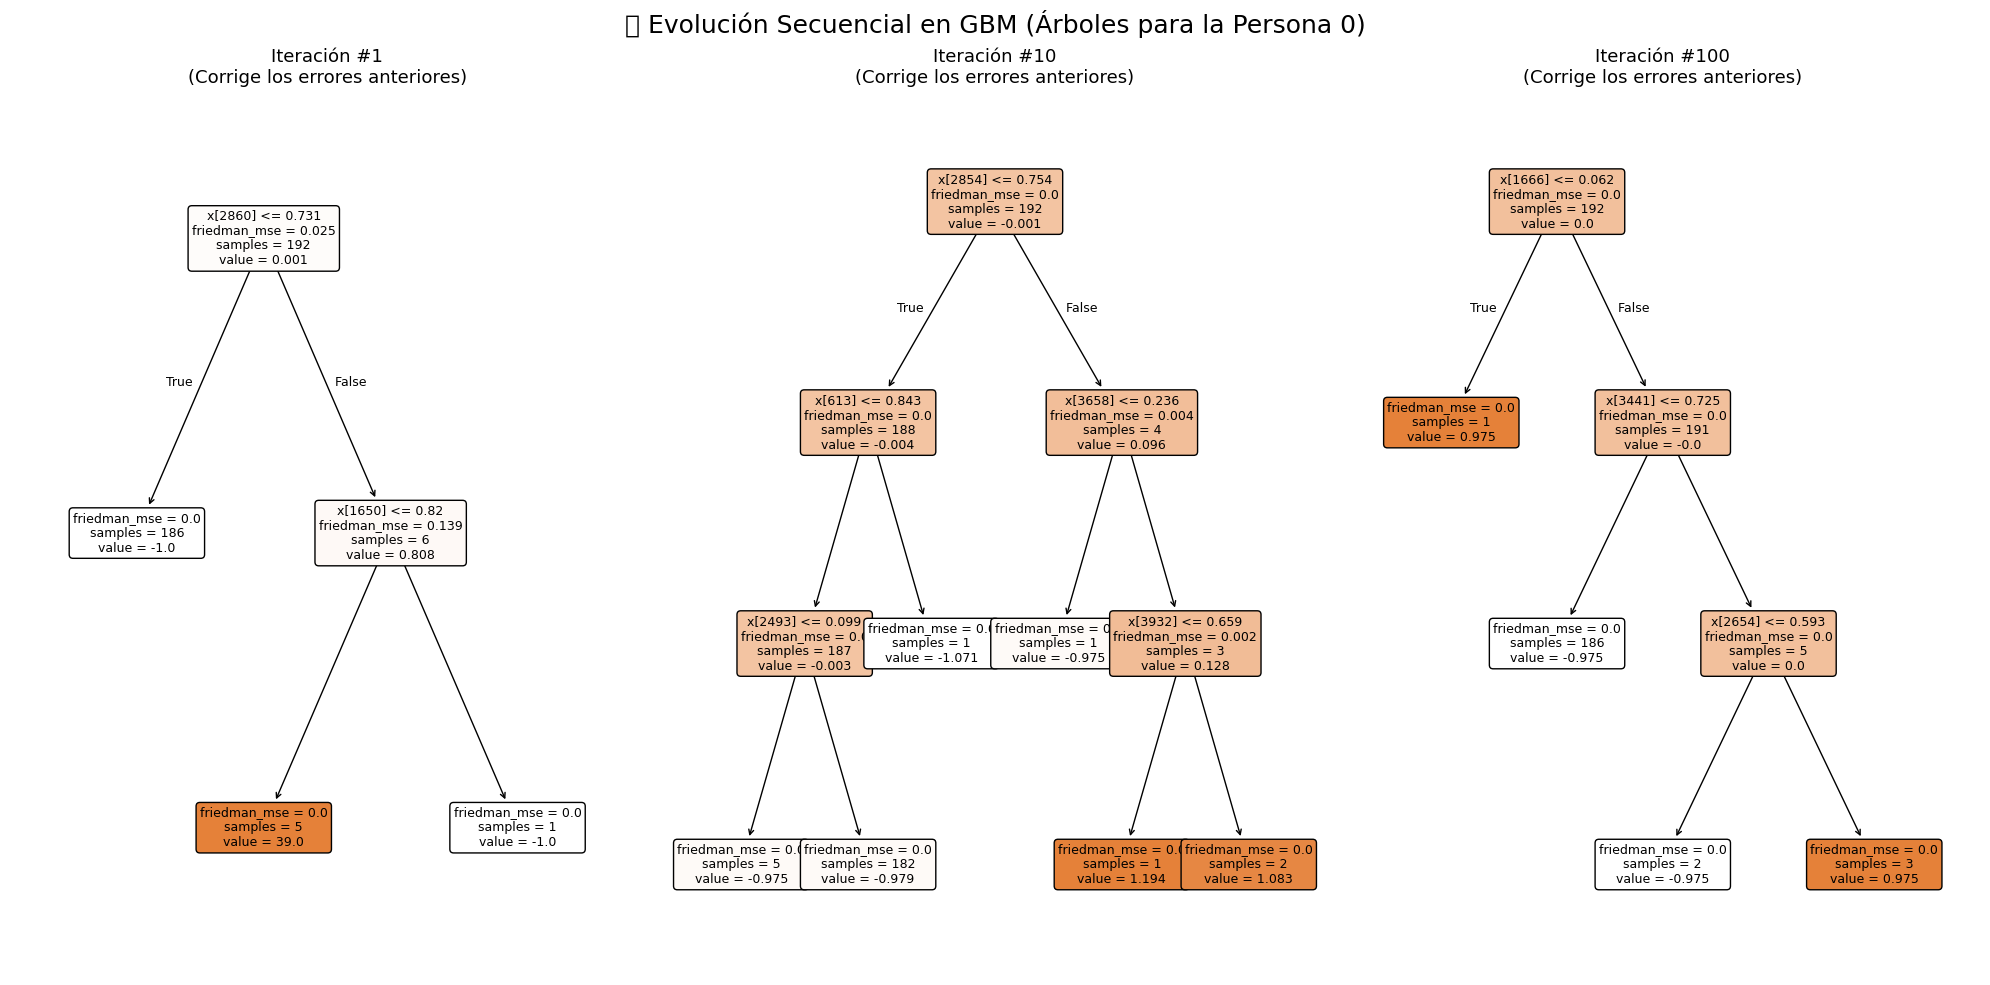

In [16]:
from sklearn.tree import plot_tree

# Seleccionamos una persona de ejemplo (Clase 0)
clase_objetivo = 0

# Seleccionamos 3 momentos en el tiempo (iteraciones)
iteraciones_a_ver = [0, 9, 99] 

plt.figure(figsize=(20, 10))
plt.suptitle(f"🚀 Evolución Secuencial en GBM (Árboles para la Persona {clase_objetivo})", fontsize=18)

for i, iteracion in enumerate(iteraciones_a_ver):
    plt.subplot(1, 3, i + 1)
    
    # Extraemos el árbol específico: [iteración, clase]
    arbol_secuencial = clf_gbm.estimators_[iteracion, clase_objetivo]
    
    # Graficamos (nota que los árboles en GBM suelen ser 'stumps' o muy bajitos)
    plot_tree(arbol_secuencial, 
              max_depth=3, 
              filled=True, 
              rounded=True, 
              fontsize=9)
    
    plt.title(f"Iteración #{iteracion + 1}\n(Corrige los errores anteriores)", fontsize=13)

plt.tight_layout()
plt.show()


### 16. Inferencia Visual con GBM
Función para inspeccionar las predicciones visuales del Gradient Boosting.


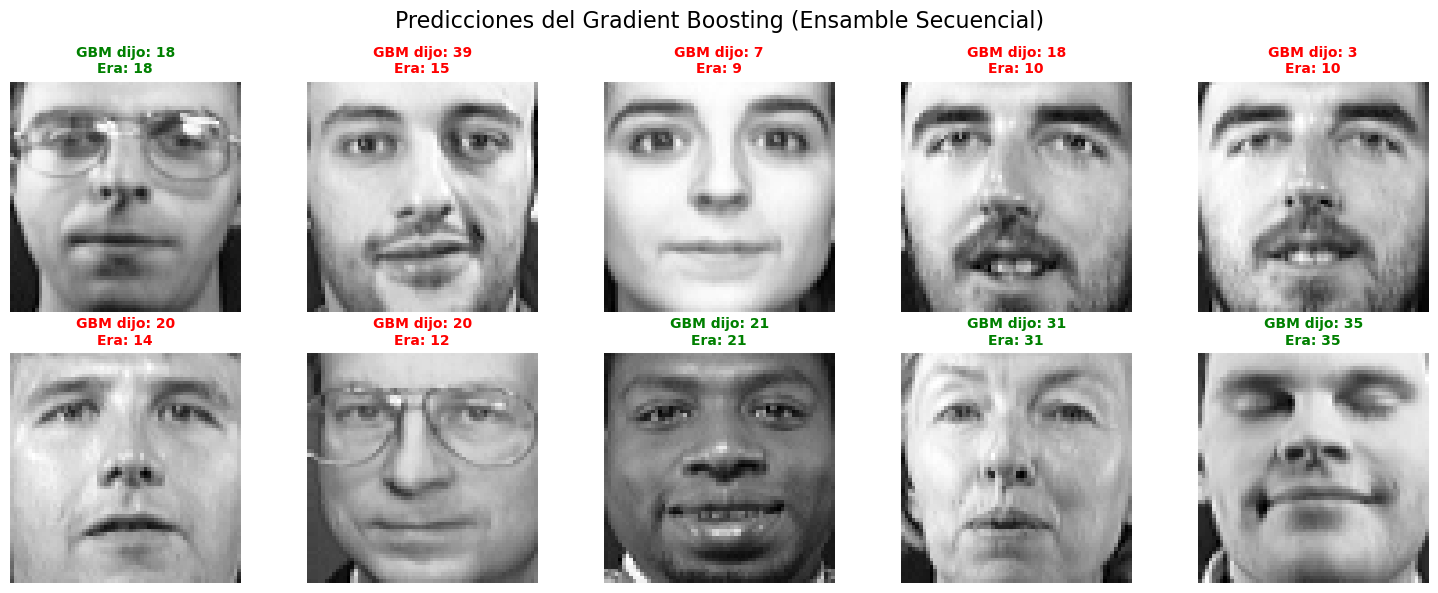

In [17]:
def visualizar_resultados_gbm(modelo, X_imagenes, y_reales, cantidad=10):
    predicciones = modelo.predict(X_imagenes)
    np.random.seed(42) # Usamos la misma semilla para que salgan las mismas caras a comparar
    indices = np.random.choice(len(y_reales), cantidad, replace=False)
    
    plt.figure(figsize=(15, 6))
    plt.suptitle("Predicciones del Gradient Boosting (Ensamble Secuencial)", fontsize=16)
    
    for i, idx in enumerate(indices):
        plt.subplot(2, 5, i + 1)
        foto = X_imagenes[idx].reshape(64, 64)
        plt.imshow(foto, cmap='gray')
        plt.axis('off')
        
        pred = predicciones[idx]
        real = y_reales[idx]
        
        color = 'green' if pred == real else 'red'
        plt.title(f"GBM dijo: {pred}\nEra: {real}", color=color, fontweight='bold', fontsize=10)
        
    plt.tight_layout()
    plt.show()

# Ejecutamos la visualización
visualizar_resultados_gbm(clf_gbm, X_test, y_test, cantidad=10)


### 17. Optimización de GBM
Entrenamos un modelo GBM optimizado ajustando hiperparámetros como el learning_rate y max_depth.


Entrenando GBM Optimizado... (Paciencia, este aprendizaje lento es más preciso)

🚀 Accuracy del GBM OPTIMIZADO: 0.9375
Diferencia respecto al anterior: +0.2750


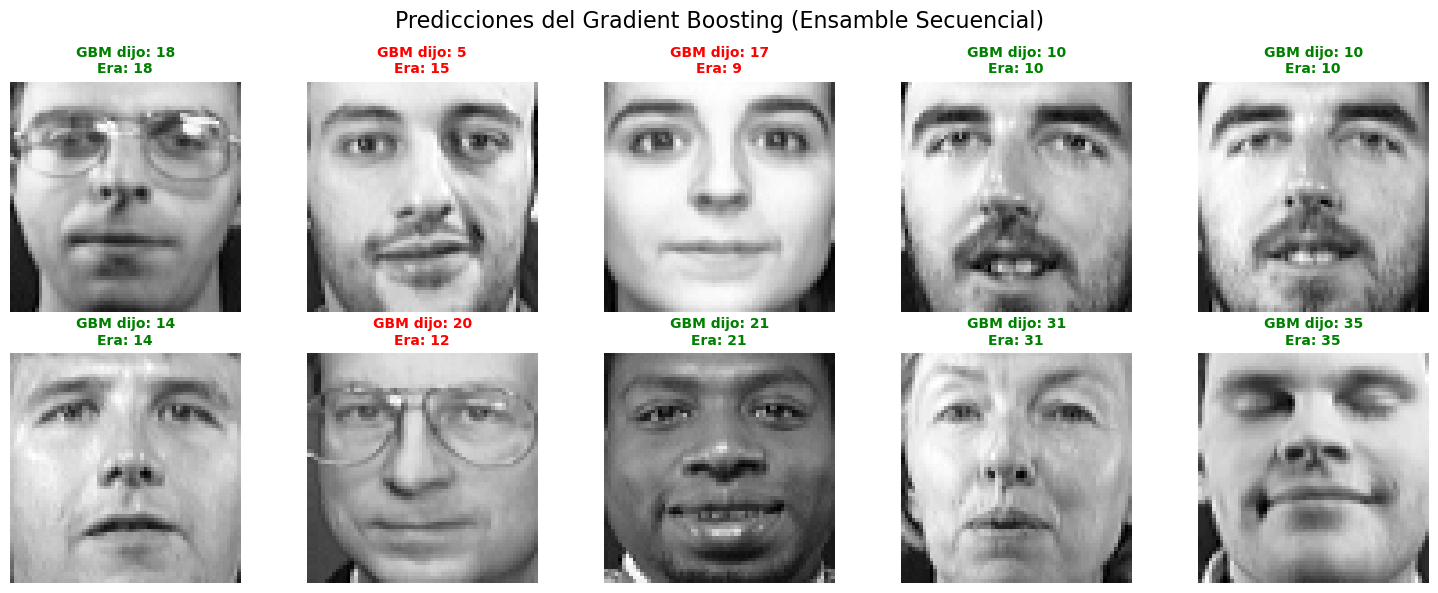

In [18]:
from sklearn.ensemble import GradientBoostingClassifier

print("Entrenando GBM Optimizado... (Paciencia, este aprendizaje lento es más preciso)")

clf_gbm_opt = GradientBoostingClassifier(
    n_estimators=300,        # Más árboles para un aprendizaje más largo
    learning_rate=0.05,      # Aprendizaje más lento y cuidadoso (mitad del anterior)
    max_depth=3,             
    max_features='sqrt',     # ¡CLAVE! Cada árbol solo ve una parte aleatoria de los píxeles
    subsample=0.8,           
    min_samples_leaf=3,      # Evita que las hojas sean demasiado específicas de una sola foto
    random_state=semilla
)

clf_gbm_opt.fit(X_train, y_train)

# Nueva evaluación
y_pred_gbm_opt = clf_gbm_opt.predict(X_val)
acc_gbm_opt = accuracy_score(y_val, y_pred_gbm_opt)

print(f"\n🚀 Accuracy del GBM OPTIMIZADO: {acc_gbm_opt:.4f}")
print(f"Diferencia respecto al anterior: {acc_gbm_opt - acc_gbm_val:+.4f}")

# Actualizamos la visualización de resultados con el nuevo modelo
visualizar_resultados_gbm(clf_gbm_opt, X_test, y_test, cantidad=10)


### 18. Support Vector Machine (SVM)
Implementamos un clasificador basado en Máquinas de Vectores de Soporte, utilizando `GridSearchCV` para encontrar los mejores hiperparámetros.


In [19]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

svm_param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly']
}

svm_clf = SVC(random_state=42, probability=True)
svm_grid = GridSearchCV(svm_clf, svm_param_grid, cv=3, n_jobs=-1, scoring='accuracy')
svm_grid.fit(X_train, y_train)

print("Mejores parámetros para SVM:", svm_grid.best_params_)
best_svm = svm_grid.best_estimator_
acc_val_svm = accuracy_score(y_val, best_svm.predict(X_val))
print(f"\n✅ Accuracy en el conjunto de VALIDACIÓN (SVM): {acc_val_svm:.4f}")


Mejores parámetros para SVM: {'C': 0.1, 'kernel': 'linear'}

✅ Accuracy en el conjunto de VALIDACIÓN (SVM): 0.9625


### 19. Random Forest Classifier
Implementamos un ensamble de Random Forest y ajustamos hiperparámetros clave como el número de estimadores y la profundidad máxima.


In [20]:
from sklearn.ensemble import RandomForestClassifier

rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf_clf = RandomForestClassifier(random_state=42)
rf_grid = GridSearchCV(rf_clf, rf_param_grid, cv=3, n_jobs=-1, scoring='accuracy')
rf_grid.fit(X_train, y_train)

print("Mejores parámetros para Random Forest:", rf_grid.best_params_)
best_rf = rf_grid.best_estimator_
acc_val_rf = accuracy_score(y_val, best_rf.predict(X_val))
print(f"\n✅ Accuracy en el conjunto de VALIDACIÓN (Random Forest): {acc_val_rf:.4f}")


Mejores parámetros para Random Forest: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

✅ Accuracy en el conjunto de VALIDACIÓN (Random Forest): 0.9625


### 20. Comparación Final de Modelos
Comparamos los modelos entrenados en este taller (Decision Tree, SVM, Random Forest) con la Red Neuronal (MLP) del Taller 3. Evaluamos Accuracy, Precision, Recall y F1-Score en el conjunto de Prueba.


In [21]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

def evaluar_modelo(modelo, nombre):
    y_pred = modelo.predict(X_test)
    return {
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, average='weighted', zero_division=0)
    }

resultados = []
resultados.append(evaluar_modelo(clf_tree, 'Decision Tree'))
resultados.append(evaluar_modelo(best_svm, 'SVM'))
resultados.append(evaluar_modelo(best_rf, 'Random Forest'))

# Agregamos los resultados del MLP del Taller 3
resultados.append({
    'Modelo': 'MLP (Taller 3)',
    'Accuracy': 0.9750,
    'Precision': 0.98,
    'Recall': 0.97,
    'F1-Score': 0.97
})

df_resultados = pd.DataFrame(resultados)
df_resultados.sort_values(by='Accuracy', ascending=False, inplace=True)
display(df_resultados)


,Modelo,Accuracy,Precision,Recall,F1-Score
1,SVM,0.9750,0.983333,0.9750,0.973333
3,MLP (Taller 3),0.9750,0.980000,0.9700,0.970000
2,Random Forest,0.9625,0.975000,0.9625,0.960000
0,Decision Tree,0.4500,0.488958,0.4500,0.438095


### 21. Matrices de Confusión
Visualizamos la matriz de confusión para los mejores modelos.


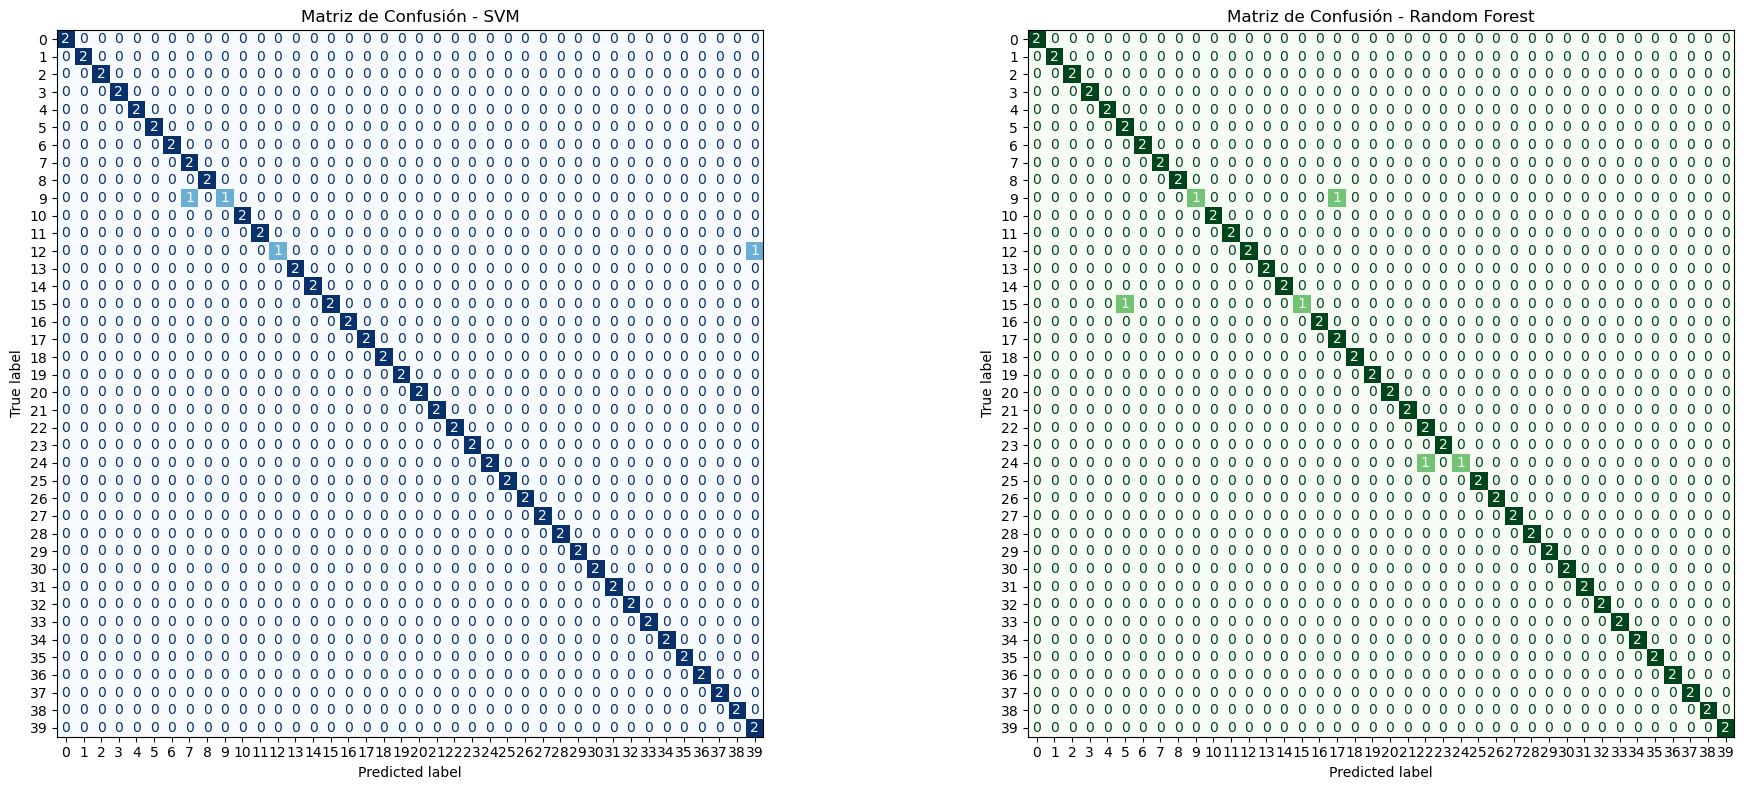

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

ConfusionMatrixDisplay.from_estimator(best_svm, X_test, y_test, ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusión - SVM')

ConfusionMatrixDisplay.from_estimator(best_rf, X_test, y_test, ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Matriz de Confusión - Random Forest')

plt.tight_layout()
plt.show()


### 22. Análisis y Conclusiones Finales

### Limitaciones de Modelos Lineales y Capacidad No Lineal
Los modelos lineales estándar sufren para separar clases en espacios tan complejos como el reconocimiento facial, donde la relación entre intensidad de píxeles y la identidad no es lineal. Modelos como el Árbol de Decisión, Random Forest, GBM o SVM (con kernel RBF) tienen la capacidad de modelar **no linealidades**, superando esta limitación y permitiendo crear fronteras de decisión mucho más complejas, ideales para imágenes.

### Impacto de la Dimensionalidad
El dataset Olivetti tiene 4096 características (64x64 píxeles). La alta dimensionalidad frecuentemente causa *'La maldición de la dimensionalidad'*. El Decision Tree puro tiende a memorizar características irrelevantes en estas dimensiones altas. En contraste, SVM y los Ensambles (RF/GBM) mitigan este impacto al usar subconjuntos de características o proyectando a espacios hiperdimensionales (kernels).

### Casos de Sobreajuste y Subajuste
- **Sobreajuste (Overfitting):** Se observó en el *Decision Tree* y *GBM Base*, donde el modelo se aprendió de memoria los datos de entrenamiento (Accuracy 1.0) pero su rendimiento cayó en Validación/Test, debido a alta profundidad sin regularización.
- **Subajuste (Underfitting):** Puede ocurrir si limitamos en exceso la profundidad (`max_depth=1` o `2`) o usamos penalizaciones `C` muy pequeñas en SVM, limitando la capacidad de capturar la fisionomía de las caras.

### Diferencias entre ML Clásico y Deep Learning (MLP)
- **Extracción de Características:** En ML Clásico, los algoritmos operan sobre píxeles crudos y dependen estadísticamente de las divisiones/márgenes, mientras que las Redes Neuronales Profundas (y especialmente CNNs, aunque aquí usamos MLP) construyen representaciones jerárquicas abstractas en sus capas ocultas.
- **Escenarios Adecuados:** El ML Clásico (como SVM o Random Forest) es excelente y rápido para tabular datasets y problemas con pocos datos (como Olivetti con 400 imágenes). Deep Learning brilla masivamente cuando los datos ascienden a miles o millones de registros y hay aceleración por hardware (GPU).
- **Complejidad vs Desempeño:** El MLP obtuvo excelentes resultados (0.975), pero requirió mucho tiempo de entrenamiento e hiperparámetros de arquitectura. En contraste, SVM alcanzó un rendimiento comparable en menor tiempo con una complejidad matemática diferente (optimización convexa), evidenciando que para este tamaño de datos, aumentar brutalmente la complejidad de red no siempre es vital si un algoritmo clásico robusto se parametriza bien.
